# NFL Elimination Picks 2026

reqs:
```
pip install requests numpy scipy pandas matplotlib parsel
```

In [1]:
import datetime
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
#%load_ext autoreload
#%autoreload 2

In [2]:
import anysunday
import anysunday.powercalcs
from anysunday import viz, pick

In [5]:
schedule = anysunday.loaders.espn_schedule("./schedules/2026.espn")

https://www.espn.com/nfl/fpi

In [6]:
powers = anysunday.loaders.espn_powers()
pd.DataFrame(powers.items()).T

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,LAR,BUF,SEA,BAL,SF,LAC,GB,DET,KC,PHI,...,NYG,ATL,NO,CAR,TEN,LV,NYJ,CLE,ARI,MIA
1,5.9,4.1,3.6,3.5,3.0,2.9,2.7,2.6,2.5,2.1,...,-1.5,-1.8,-2.8,-2.9,-4.0,-4.7,-4.7,-5.3,-5.4,-6.1


In [7]:
picks = [
    "LAC", # week 1
    # "BAL", # week 2
    # "SEA", # week 3
    # "BUF", # week 4
    # "ARI", # week 5
]

(<Figure size 800x1000 with 2 Axes>,
 <Axes: xlabel='Week', ylabel='Pick to Win'>)

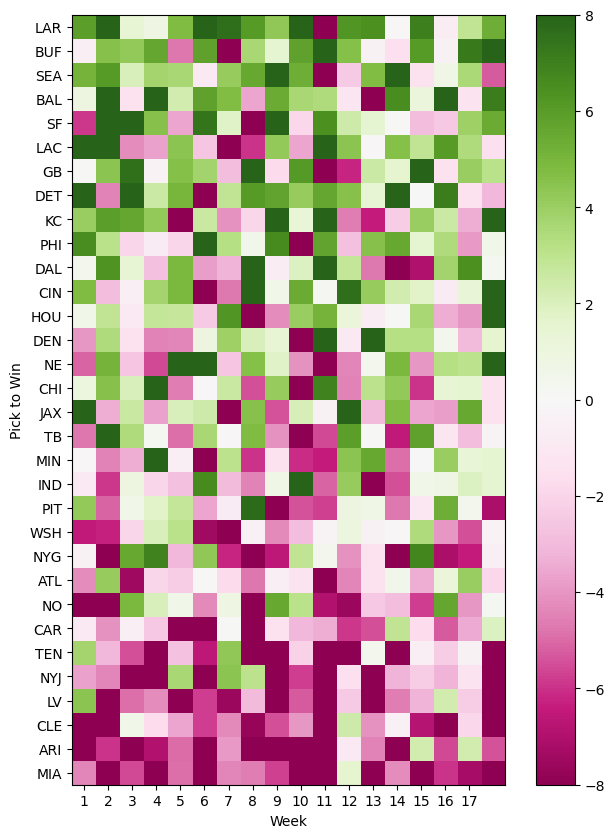

In [8]:
power_rank, matrix = anysunday.powercalcs.pick_grid(powers, schedule, home_bump=3)

viz.plot_matrix(matrix, power_rank)

In [9]:
tuned_home_bump = 3  # default is 3

ppkwargs = {
    "powers": powers,
    "schedule": schedule,
    "home_bump": tuned_home_bump,
    "past_picks": picks
}

In [10]:
pp = pick.Permuter(**ppkwargs)

pprev = pick.Permuter(**ppkwargs)
pprev.pick = pprev.reverse_greedy()

pprand = pick.Permuter(**ppkwargs)
pprand.pick = pprand.random_greedy()

pplg = pick.Permuter(**ppkwargs)
pplg.pick = pplg.limited_greedy(limit=8)

In [11]:
pp.describe_pick()

week  2: diff +12.1 - picking SF  (+3.0+H) over MIA (-6.1  )
week  3: diff +10.3 - picking DET (+2.6+H) over NYJ (-4.7  )
week  4: diff +10.5 - picking BAL (+3.5+H) over TEN (-4.0  )
week  5: diff  +9.2 - picking NE  (+1.5+H) over LV  (-4.7  )
week  6: diff +14.3 - picking LAR (+5.9+H) over ARI (-5.4  )
week  7: diff  +6.2 - picking HOU (+1.7+H) over NYG (-1.5  )
week  8: diff +10.3 - picking DAL (+1.9+H) over ARI (-5.4  )
week  9: diff +12.0 - picking SEA (+3.6+H) over ARI (-5.4  )
week 10: diff  +8.7 - picking IND (-0.4+H) over MIA (-6.1  )
week 11: diff +13.2 - picking BUF (+4.1+H) over MIA (-6.1  )
week 12: diff  +8.1 - picking JAX (+1.1+H) over TEN (-4.0  )
week 13: diff +10.6 - picking DEN (+1.5+H) over MIA (-6.1  )
week 14: diff  +5.5 - picking PHI (+2.1+H) over IND (-0.4  )
week 15: diff +11.8 - picking GB  (+2.7+H) over MIA (-6.1  )
week 16: diff  +5.6 - picking NO  (-2.8+H) over ARI (-5.4  )
week 17: diff  +4.0 - picking ATL (-1.8+H) over NO  (-2.8  )
week 18: diff +10.2 - pi

In [12]:
pprev.describe_pick()

week  2: diff  +8.3 - picking TB  (+0.0+H) over CLE (-5.3  )
week  3: diff +11.4 - picking SF  (+3.0+H) over ARI (-5.4  )
week  4: diff  +8.8 - picking CHI (+1.1+H) over NYJ (-4.7  )
week  5: diff  +3.6 - picking NYJ (-4.7+H) over CLE (-5.3  )
week  6: diff  +9.2 - picking NE  (+1.5+H) over NYJ (-4.7  )
week  7: diff  +7.6 - picking LAR (+5.9  ) over LV  (-4.7+H)
week  8: diff  +8.8 - picking CIN (+1.8+H) over TEN (-4.0  )
week  9: diff +12.0 - picking SEA (+3.6+H) over ARI (-5.4  )
week 10: diff  +8.7 - picking IND (-0.4+H) over MIA (-6.1  )
week 11: diff +10.9 - picking KC  (+2.5+H) over ARI (-5.4  )
week 12: diff  +8.1 - picking JAX (+1.1+H) over TEN (-4.0  )
week 13: diff +10.6 - picking DEN (+1.5+H) over MIA (-6.1  )
week 14: diff  +9.6 - picking DET (+2.6+H) over TEN (-4.0  )
week 15: diff +11.8 - picking GB  (+2.7+H) over MIA (-6.1  )
week 16: diff +11.8 - picking BAL (+3.5+H) over CLE (-5.3  )
week 17: diff  +6.4 - picking DAL (+1.9+H) over NYG (-1.5  )
week 18: diff +11.8 - pi

In [13]:
pprand.describe_pick()

week  2: diff  +9.3 - picking BAL (+3.5+H) over NO  (-2.8  )
week  3: diff +11.4 - picking SF  (+3.0+H) over ARI (-5.4  )
week  4: diff  +8.8 - picking CHI (+1.1+H) over NYJ (-4.7  )
week  5: diff  +4.9 - picking CIN (+1.8  ) over MIA (-6.1+H)
week  6: diff  +4.3 - picking NYG (-1.5+H) over NO  (-2.8  )
week  7: diff  +7.6 - picking LAR (+5.9  ) over LV  (-4.7+H)
week  8: diff  +7.7 - picking PIT (-0.6+H) over CLE (-5.3  )
week  9: diff +12.0 - picking SEA (+3.6+H) over ARI (-5.4  )
week 10: diff  +8.7 - picking IND (-0.4+H) over MIA (-6.1  )
week 11: diff +13.2 - picking BUF (+4.1+H) over MIA (-6.1  )
week 12: diff  +8.1 - picking JAX (+1.1+H) over TEN (-4.0  )
week 13: diff +10.6 - picking DEN (+1.5+H) over MIA (-6.1  )
week 14: diff  +5.5 - picking PHI (+2.1+H) over IND (-0.4  )
week 15: diff +11.8 - picking GB  (+2.7+H) over MIA (-6.1  )
week 16: diff  +7.1 - picking DET (+2.6+H) over NYG (-1.5  )
week 17: diff  +6.4 - picking DAL (+1.9+H) over NYG (-1.5  )
week 18: diff +10.6 - pi

In [14]:
pplg.describe_pick()

week  2: diff  +8.3 - picking TB  (+0.0+H) over CLE (-5.3  )
week  3: diff +10.3 - picking DET (+2.6+H) over NYJ (-4.7  )
week  4: diff  +8.7 - picking MIN (-0.4+H) over MIA (-6.1  )
week  5: diff  +9.2 - picking NE  (+1.5+H) over LV  (-4.7  )
week  6: diff +14.3 - picking LAR (+5.9+H) over ARI (-5.4  )
week  7: diff  +6.2 - picking HOU (+1.7+H) over NYG (-1.5  )
week  8: diff  +8.6 - picking GB  (+2.7+H) over CAR (-2.9  )
week  9: diff +10.2 - picking KC  (+2.5+H) over NYJ (-4.7  )
week 10: diff  +8.7 - picking IND (-0.4+H) over MIA (-6.1  )
week 11: diff  +8.9 - picking DAL (+1.9+H) over TEN (-4.0  )
week 12: diff  +8.1 - picking JAX (+1.1+H) over TEN (-4.0  )
week 13: diff +10.6 - picking DEN (+1.5+H) over MIA (-6.1  )
week 14: diff  +8.1 - picking SEA (+3.6+H) over NYG (-1.5  )
week 15: diff  +6.8 - picking NYG (-1.5+H) over CLE (-5.3  )
week 16: diff +11.8 - picking BAL (+3.5+H) over CLE (-5.3  )
week 17: diff  +7.2 - picking BUF (+4.1  ) over MIA (-6.1+H)
week 18: diff +10.1 - pi